In [ ]:
# ==============================================================================
# 1. 라이브러리 설치 및 데이터 다운로드
# ==============================================================================
!pip install efficientnet_pytorch
!pip install kagglehub
!pip install torchmetrics

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import os
import kagglehub
import time
import copy
from collections import Counter
from google.colab import drive
from torch.cuda.amp import GradScaler, autocast 

# GPU 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")


print("농작물 데이터셋 다운로드 중...")
path = kagglehub.dataset_download("mdwaquarazam/agricultural-crops-image-classification")
print("다운로드 완료:", path)

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=c1e516432e4889634faac71440de44ec7778a0f662fe3ed8a098fbaf028a7099
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.6 MB/s eta 0:00:00
사용 장치: cuda:0
농작물 데이터셋 다운로드 중...


100%|██████████| 79.0M/79.0M [00:04<00:00, 18.2MB/s]

Extracting files...


다운로드 완료: /root/.cache/kagglehub/datasets/mdwaquarazam/agricultural-crops-image-classification/versions/1


In [ ]:
# ==============================================================================
# 2. 데이터셋 실제 경로 찾기
# ==============================================================================

DATA_ROOT_FOR_SPLIT = path


for root, dirs, files in os.walk(path):
    if len(dirs) > 5: 
        DATA_ROOT_FOR_SPLIT = root
        break

print(f"✅ 최종 데이터 로드 경로: {DATA_ROOT_FOR_SPLIT}")
print(f"   (폴더 목록 예시: {os.listdir(DATA_ROOT_FOR_SPLIT)[:5]}...)")

✅ 최종 데이터 로드 경로: /root/.cache/kagglehub/datasets/mdwaquarazam/agricultural-crops-image-classification/versions/1/Agricultural-crops
   (폴더 목록 예시: ['soyabean', 'clove', 'cardamom', 'papaya', 'maize']...)


In [ ]:
# ==============================================================================
# 3. 하이퍼파라미터 및 데이터 변환 
# ==============================================================================
from efficientnet_pytorch import EfficientNet

BATCH_SIZE = 64
NUM_EPOCHS = 20  
LEARNING_RATE = 0.0005 
MODEL_NAME = 'efficientnet-b0'

INPUT_SIZE = EfficientNet.get_image_size(MODEL_NAME)

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.8, 1.0)), 
        transforms.RandomRotation(30), 
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(), 
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)) 
    ]),
    'val': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.CenterCrop(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [ ]:
# ==============================================================================
# 4. 데이터 로드 및 분할
# ==============================================================================
# 데이터셋 로드
full_dataset = ImageFolder(DATA_ROOT_FOR_SPLIT, data_transforms['train'])
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

# 데이터 분할 (90% 학습, 10% 검증)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

print(f"총 작물 종류: {NUM_CLASSES}개")
print(f"작물 목록: {class_names[:5]} ...")
print(f"학습 데이터: {dataset_sizes['train']}장, 검증 데이터: {dataset_sizes['val']}장")

총 작물 종류: 30개
작물 목록: ['Cherry', 'Coffee-plant', 'Cucumber', 'Fox_nut(Makhana)', 'Lemon'] ...
학습 데이터: 746장, 검증 데이터: 83장


In [ ]:
# ==============================================================================
# 5. 모델 및 옵티마이저 설정 
# ==============================================================================
# 1. 클래스 가중치 
train_targets = full_dataset.targets
class_counts = Counter(train_targets)
total_count = sum(class_counts.values())
class_weights = torch.tensor([total_count / (class_counts[i] + 1) for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
class_weights = class_weights / class_weights.min()

# 2. 모델 로드 및 Dropout 강화
model_ft = EfficientNet.from_pretrained(MODEL_NAME)
num_ftrs = model_ft._fc.in_features

model_ft._fc = nn.Sequential(
    nn.Dropout(0.6), 
    nn.Linear(num_ftrs, NUM_CLASSES)
)
model_ft = model_ft.to(device)


criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer_ft = optim.AdamW(model_ft.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)


exp_lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=3)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 35.6MB/s]


Loaded pretrained weights for efficientnet-b0


In [ ]:
# ==============================================================================
# 6. 고속 학습 함수 
# ==============================================================================
def train_model_tuned(model, criterion, optimizer, scheduler, num_epochs=20, patience=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf') 

    early_stopping_counter = 0 # 조기 종료 카운터
    scaler = GradScaler()

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast():
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            
            if phase == 'val':
                scheduler.step(epoch_loss) 

                # 모델 저장 조건: 정확도가 오르거나, 손실이 줄었을 때
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

                
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    early_stopping_counter = 0 
                    print(f'-> Val Loss improved to {best_loss:.4f}. Reset counter.')
                else:
                    early_stopping_counter += 1
                    print(f'-> No improvement. Counter: {early_stopping_counter}/{patience}')

        # 조기 종료 체크
        if early_stopping_counter >= patience:
            print(f'\nEarly Stopping triggered at epoch {epoch+1}!')
            break

    time_elapsed = time.time() - since
    print(f'\n학습 완료! 소요 시간: {time_elapsed // 60:.0f}분 {time_elapsed % 60:.0f}초')
    print(f'최고 검증 정확도: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [ ]:
# ==============================================================================
# 7. 실행
# ==============================================================================

model_ft = train_model_tuned(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS, patience=5)


drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/agricultural_crop_model_tuned.pth'
torch.save(model_ft.state_dict(), SAVE_PATH)
print(f"✅ 튜닝된 모델 저장 완료: {SAVE_PATH}")


Epoch 1/20
----------


/tmp/ipython-input-1954469794.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1954469794.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


train Loss: 3.3845 Acc: 0.0442
val Loss: 3.1772 Acc: 0.2048
-> Val Loss improved to 3.1772. Reset counter.

Epoch 2/20
----------
train Loss: 3.0365 Acc: 0.2386
val Loss: 2.8533 Acc: 0.3494
-> Val Loss improved to 2.8533. Reset counter.

Epoch 3/20
----------
train Loss: 2.5531 Acc: 0.4504
val Loss: 2.4066 Acc: 0.3735
-> Val Loss improved to 2.4066. Reset counter.

Epoch 4/20
----------
train Loss: 2.0351 Acc: 0.5590
val Loss: 2.0154 Acc: 0.5181
-> Val Loss improved to 2.0154. Reset counter.

Epoch 5/20
----------
train Loss: 1.5486 Acc: 0.6340
val Loss: 1.6291 Acc: 0.5301
-> Val Loss improved to 1.6291. Reset counter.

Epoch 6/20
----------
train Loss: 1.2089 Acc: 0.7118
val Loss: 1.5116 Acc: 0.5663
-> Val Loss improved to 1.5116. Reset counter.

Epoch 7/20
----------
train Loss: 0.8661 Acc: 0.7976
val Loss: 1.3468 Acc: 0.5904
-> Val Loss improved to 1.3468. Reset counter.

Epoch 8/20
----------
train Loss: 0.6943 Acc: 0.8298
val Loss: 1.1577 Acc: 0.6506
-> Val Loss improved to 1.1577

In [ ]:
# ==============================================================================
# [코드 1] 최종 검증 데이터셋(Final Dataset) 정의 및 메타데이터 저장
# ==============================================================================
import pandas as pd
import os


final_dataset = val_dataset
print(f"최종 평가 데이터 개수: {len(final_dataset)}개")


def create_dataset_metadata(dataset, class_names):
    data_list = []
    
    if hasattr(dataset, 'indices'):
        for idx in dataset.indices:
            path, label_idx = dataset.dataset.samples[idx]
            data_list.append({
                'file_path': path,
                'file_name': os.path.basename(path),
                'label_index': label_idx,
                'class_name': class_names[label_idx]
            })
    else:
        
        for path, label_idx in dataset.samples:
            data_list.append({
                'file_path': path,
                'file_name': os.path.basename(path),
                'label_index': label_idx,
                'class_name': class_names[label_idx]
            })

    return pd.DataFrame(data_list)

# 3. 메타데이터 생성 및 CSV 저장
df_final = create_dataset_metadata(final_dataset, class_names)
df_final.to_csv('final_crop_dataset_metadata.csv', index=False, encoding='utf-8-sig')

print("✅ 최종 데이터셋 메타데이터 저장 완료: final_crop_dataset_metadata.csv")
display(df_final.head()) 

최종 평가 데이터 개수: 83개
✅ 최종 데이터셋 메타데이터 저장 완료: final_crop_dataset_metadata.csv


,file_path,file_name,label_index,class_name
0,/root/.cache/kagglehub/datasets/mdwaquarazam/a...,image (10).jpeg,10,cardamom
1,/root/.cache/kagglehub/datasets/mdwaquarazam/a...,image (7).jpg,5,Olive-tree
2,/root/.cache/kagglehub/datasets/mdwaquarazam/a...,image (2).jpg,27,tomato
3,/root/.cache/kagglehub/datasets/mdwaquarazam/a...,image (19).jpg,6,Pearl_millet(bajra)
4,/root/.cache/kagglehub/datasets/mdwaquarazam/a...,image16.jpeg,7,Tobacco-plant


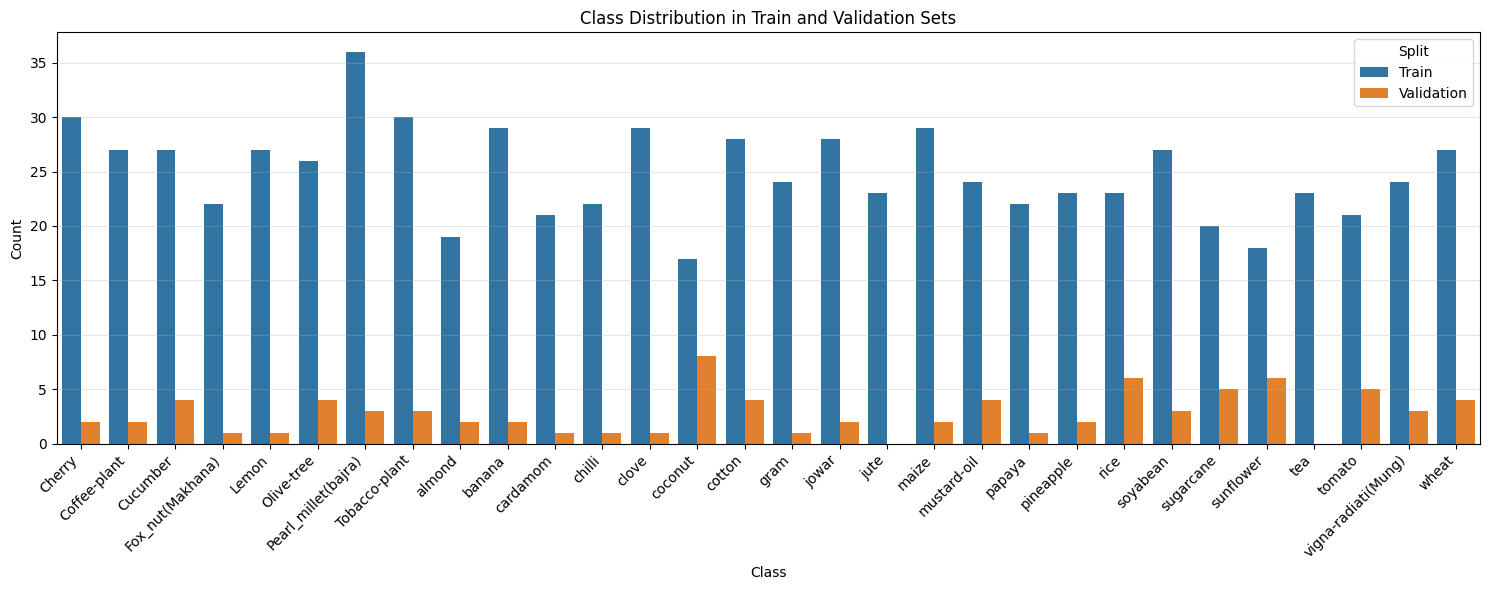

In [ ]:
# ==============================================================================
# [시각화 1] 클래스별 데이터 분포 (Data Distribution)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 학습/검증 데이터의 라벨 분포 계산
def get_label_counts(dataset):
    if hasattr(dataset, 'indices'):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets
    return Counter(labels)

train_counts = get_label_counts(train_dataset)
val_counts = get_label_counts(val_dataset)

# 데이터프레임으로 변환
plot_data = []
for idx, name in enumerate(class_names):
    plot_data.append({'Class': name, 'Count': train_counts[idx], 'Split': 'Train'})
    plot_data.append({'Class': name, 'Count': val_counts[idx], 'Split': 'Validation'})
df_plot = pd.DataFrame(plot_data)

# 시각화
plt.figure(figsize=(15, 6))
sns.barplot(data=df_plot, x='Class', y='Count', hue='Split')
plt.title('Class Distribution in Train and Validation Sets')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png') 
plt.show()


             Final Classification Report
                     precision    recall  f1-score   support

             Cherry       1.00      0.50      0.67         2
       Coffee-plant       0.50      1.00      0.67         2
           Cucumber       0.80      1.00      0.89         4
   Fox_nut(Makhana)       0.50      1.00      0.67         1
              Lemon       1.00      1.00      1.00         1
         Olive-tree       1.00      0.25      0.40         4
Pearl_millet(bajra)       0.75      1.00      0.86         3
      Tobacco-plant       1.00      0.33      0.50         3
             almond       0.50      0.50      0.50         2
             banana       0.67      1.00      0.80         2
           cardamom       1.00      1.00      1.00         1
             chilli       1.00      1.00      1.00         1
              clove       0.00      0.00      0.00         1
            coconut       1.00      0.88      0.93         8
             cotton       0.80      1.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

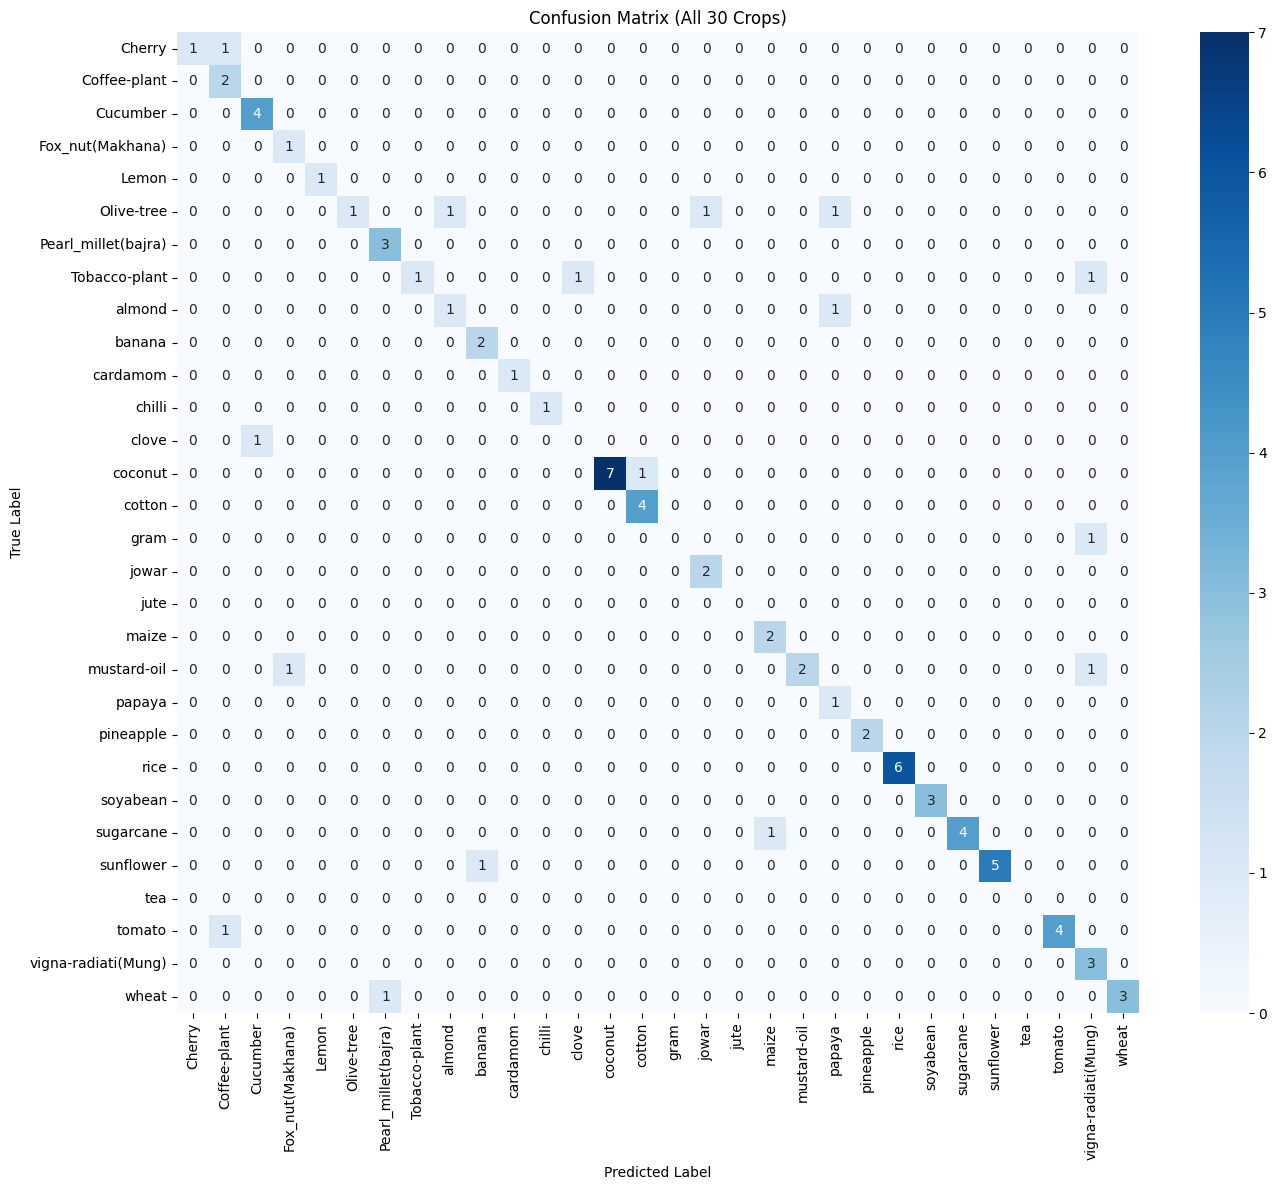

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. 모든 클래스 인덱스 리스트 생성 
all_labels = list(range(len(class_names)))

# 2. 분류 리포트 
print("\n" + "="*50)
print("             Final Classification Report")
print("="*50)

print(classification_report(y_true, y_pred, target_names=class_names, labels=all_labels))

# 3. 혼동 행렬 시각화 
cm = confusion_matrix(y_true, y_pred, labels=all_labels)

plt.figure(figsize=(14, 12)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (All 30 Crops)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

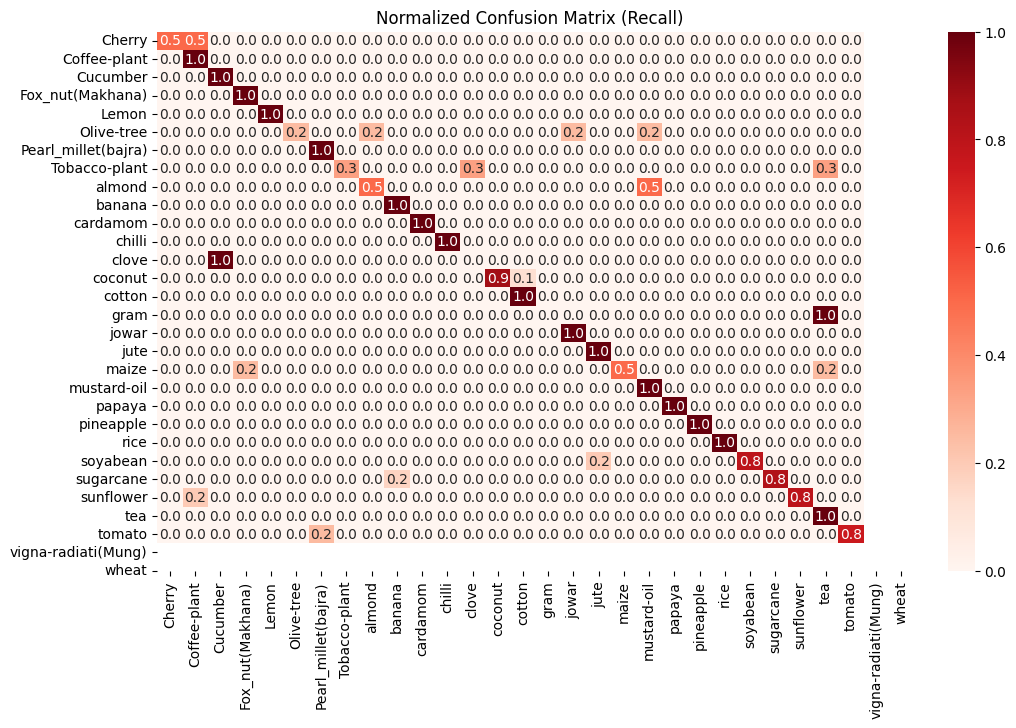

In [14]:
# 정규화된 혼동 행렬
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(12, 7))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Recall)')
plt.show()